# Desafio Final — Análise Financeira ClearBank

Este notebook processa o arquivo `transacoes.csv`, valida os dados, gera métricas mensais, identifica transações suspeitas e exporta o resultado em `relatorio.json`.

**Antes de executar:** certifique-se de que o arquivo `transacoes.csv` está na mesma pasta deste notebook.

## Célula 1 — Imports e Constantes

In [31]:
import csv
import json
from datetime import datetime

ARQUIVO_CSV  = 'transacoes.csv'
ARQUIVO_JSON = 'relatorio.json'
LIMITE_SUSPEITO = 10000.00

print('Imports e constantes carregados com sucesso.')

Imports e constantes carregados com sucesso.


## Célula 2 — Funções de Leitura e Validação

In [32]:
def _converter_data(texto: str):
    """Converte string AAAA-MM-DD em datetime. Levanta ValueError se inválido."""
    return datetime.strptime(texto.strip(), '%Y-%m-%d')


def _converter_valor(texto: str) -> float:
    """Converte string em float positivo. Levanta ValueError se inválido."""
    valor = float(texto.strip())
    if valor <= 0:
        raise ValueError(f'Valor deve ser maior que zero: {valor}')
    return valor


def validar_transacao(linha: dict):
    """
    Valida uma linha do CSV.
    Retorna (registro_limpo, None) se válida, ou (None, motivo) se inválida.
    """
    # id: deve ser inteiro
    try:
        id_transacao = int(linha.get('id', '').strip())
    except (ValueError, AttributeError):
        return None, 'id inválido ou vazio'

    # cliente_id: não pode ser vazio
    cliente_id = linha.get('cliente_id', '').strip()
    if not cliente_id:
        return None, 'cliente_id vazio'

    # data: formato AAAA-MM-DD
    try:
        data = _converter_data(linha.get('data', ''))
    except (ValueError, KeyError):
        return None, 'data inválida'

    # tipo: credito ou debito
    tipo = linha.get('tipo', '').strip().lower()
    if tipo not in ('credito', 'debito'):
        return None, f'tipo inválido: {tipo}'

    # valor: numérico e maior que zero
    try:
        valor = _converter_valor(linha.get('valor', ''))
    except (ValueError, AttributeError):
        return None, 'valor inválido ou não positivo'

    registro = {
        'id': id_transacao,
        'data': data,
        'mes': data.strftime('%Y-%m'),
        'cliente_id': cliente_id,
        'tipo': tipo,
        'valor': valor,
        'descricao': linha.get('descricao', '').strip(),
        'categoria': linha.get('categoria', '').strip(),
    }
    return registro, None


def ler_transacoes(caminho: str):
    """
    Lê o CSV e retorna (validas, invalidas).
    validas: lista de dicts limpos
    invalidas: lista de dicts {'linha': int, 'motivo': str}
    """
    validas = []
    invalidas = []

    try:
        with open(caminho, encoding='utf-8', newline='') as arquivo:
            leitor = csv.DictReader(arquivo)
            for numero, linha in enumerate(leitor, start=2):  # linha 1 = cabeçalho
                registro, motivo = validar_transacao(linha)
                if registro:
                    validas.append(registro)
                else:
                    invalidas.append({'linha': numero, 'motivo': motivo})
    except FileNotFoundError:
        print(f'[ERRO] Arquivo não encontrado: {caminho}')
        raise

    return validas, invalidas


print('Funções de leitura e validação definidas.')

Funções de leitura e validação definidas.


### Leitura e validação

In [33]:
validas_teste, invalidas_teste = ler_transacoes(ARQUIVO_CSV)
print(f'Total de linhas lidas: {len(validas_teste) + len(invalidas_teste)}')
print(f'Linhas válidas:   {len(validas_teste)}')
print(f'Linhas inválidas: {len(invalidas_teste)}')
print()
print('Detalhes das inválidas:')
for inv in invalidas_teste:
    print(f'  Linha {inv["linha"]}: {inv["motivo"]}')

Total de linhas lidas: 30
Linhas válidas:   24
Linhas inválidas: 6

Detalhes das inválidas:
  Linha 4: valor inválido ou não positivo
  Linha 5: cliente_id vazio
  Linha 27: data inválida
  Linha 28: valor inválido ou não positivo
  Linha 29: valor inválido ou não positivo
  Linha 30: data inválida


## Célula 3 — Funções de Métricas e Relatório

In [34]:
def _fmt_brl(valor: float) -> str:
    """Formata float como moeda brasileira: R$ 1.234,56"""
    return f'R$ {valor:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')


def gerar_relatorio(validas: list) -> dict:
    """
    Agrupa transações por mês e calcula métricas.
    Retorna dict com resumo_mensal e transacoes_suspeitas.
    """
    resumo: dict[str, dict] = {}
    suspeitas = []

    for t in validas:
        mes = t['mes']

        if mes not in resumo:
            resumo[mes] = {
                'quantidade': 0,
                'total_credito': 0.0,
                'total_debito': 0.0,
                'saldo': 0.0,
                'media': 0.0,
                'maior_valor': 0.0,
                'menor_valor': float('inf'),
                '_soma_valores': 0.0,
            }

        m = resumo[mes]
        m['quantidade'] += 1
        m['_soma_valores'] += t['valor']

        if t['tipo'] == 'credito':
            m['total_credito'] += t['valor']
        else:
            m['total_debito'] += t['valor']

        if t['valor'] > m['maior_valor']:
            m['maior_valor'] = t['valor']
        if t['valor'] < m['menor_valor']:
            m['menor_valor'] = t['valor']

        if t['valor'] > LIMITE_SUSPEITO:
            suspeitas.append(t)

    # calcular saldo e média depois de processar todas as transações do mês
    for mes, m in resumo.items():
        m['saldo'] = round(m['total_credito'] - m['total_debito'], 2)
        m['media'] = round(m['_soma_valores'] / m['quantidade'], 2)
        m['total_credito'] = round(m['total_credito'], 2)
        m['total_debito'] = round(m['total_debito'], 2)
        m['maior_valor'] = round(m['maior_valor'], 2)
        m['menor_valor'] = round(m['menor_valor'], 2) if m['menor_valor'] != float('inf') else 0.0
        del m['_soma_valores']

    return {
        'resumo_mensal': dict(sorted(resumo.items())),
        'transacoes_suspeitas': suspeitas,
    }


def _periodo(validas: list) -> tuple:
    """Retorna (data_mais_antiga, data_mais_recente, dias_entre_elas)."""
    datas = [t['data'] for t in validas]
    mais_antiga = min(datas)
    mais_recente = max(datas)
    dias = (mais_recente - mais_antiga).days
    return mais_antiga, mais_recente, dias


def exibir_relatorio(validas: list, invalidas: list, relatorio: dict) -> None:
    """Imprime o relatório formatado no terminal."""
    mais_antiga, mais_recente, dias = _periodo(validas)

    print('=' * 50)
    print('       ANÁLISE FINANCEIRA — CLEARBANK')
    print('=' * 50)
    print(f'Período analisado : {mais_antiga.strftime("%d/%m/%Y")} → {mais_recente.strftime("%d/%m/%Y")}')
    print(f'Dias cobertos      : {dias} dias')
    print(f'Transações válidas : {len(validas)}')
    print(f'Transações inválidas: {len(invalidas)}')
    print()

    print('===== RESUMO DA LIMPEZA =====')
    print(f'Total de linhas lidas: {len(validas) + len(invalidas)}')
    print(f'Linhas válidas:        {len(validas)}')
    print(f'Linhas inválidas:      {len(invalidas)}')
    if invalidas:
        for inv in invalidas:
            print(f'  • Linha {inv["linha"]}: {inv["motivo"]}')
    print()

    print('===== RELATÓRIO MENSAL =====')
    for mes, m in relatorio['resumo_mensal'].items():
        print()
        print(f'Mês: {mes}')
        print(f'  Transações : {m["quantidade"]}')
        print(f'  Total crédito: {_fmt_brl(m["total_credito"])}')
        print(f'  Total débito : {_fmt_brl(m["total_debito"])}')
        print(f'  Saldo        : {_fmt_brl(m["saldo"])}')
        print(f'  Média        : {_fmt_brl(m["media"])}')
        print(f'  Maior valor  : {_fmt_brl(m["maior_valor"])}')
        print(f'  Menor valor  : {_fmt_brl(m["menor_valor"])}')
    print()

    print('===== TRANSAÇÕES SUSPEITAS =====')
    suspeitas = relatorio['transacoes_suspeitas']
    if suspeitas:
        for s in suspeitas:
            print(f'ID: {s["id"]} | Cliente: {s["cliente_id"]} | '
                  f'Data: {s["data"].strftime("%Y-%m-%d")} | Valor: {_fmt_brl(s["valor"])}')
    else:
        print('Nenhuma transação suspeita encontrada.')
    print()


print('Funções de métricas e relatório definidas.')

Funções de métricas e relatório definidas.


### Métricas

In [35]:
rel_teste = gerar_relatorio(validas_teste)
print('Meses encontrados:', list(rel_teste['resumo_mensal'].keys()))
print('Suspeitas encontradas:', len(rel_teste['transacoes_suspeitas']))
primeiro_mes = list(rel_teste['resumo_mensal'].keys())[0]
print(f'\nDados do mês {primeiro_mes}:', rel_teste['resumo_mensal'][primeiro_mes])

Meses encontrados: ['2026-01', '2026-02', '2026-03', '2026-04']
Suspeitas encontradas: 3

Dados do mês 2026-01: {'quantidade': 5, 'total_credito': 11800.0, 'total_debito': 630.5, 'saldo': 11169.5, 'media': 2486.1, 'maior_valor': 5500.0, 'menor_valor': 180.5}


## Célula 4 — Função de Exportação JSON

In [36]:
def salvar_json(validas: list, invalidas: list, relatorio: dict, caminho: str) -> None:
    """Serializa o relatório e salva em arquivo JSON."""
    mais_antiga, mais_recente, dias = _periodo(validas)

    dados = {
        'gerado_em': datetime.today().strftime('%Y-%m-%d'),
        'periodo': {
            'inicio': mais_antiga.strftime('%Y-%m-%d'),
            'fim': mais_recente.strftime('%Y-%m-%d'),
            'dias_cobertos': dias,
        },
        'total_transacoes_validas': len(validas),
        'total_transacoes_invalidas': len(invalidas),
        'resumo_mensal': relatorio['resumo_mensal'],
        'transacoes_suspeitas': [
            {
                'id': s['id'],
                'cliente_id': s['cliente_id'],
                'data': s['data'].strftime('%Y-%m-%d'),
                'tipo': s['tipo'],
                'valor': s['valor'],
                'descricao': s['descricao'],
            }
            for s in relatorio['transacoes_suspeitas']
        ],
        'linhas_invalidas': invalidas,
    }

    try:
        with open(caminho, 'w', encoding='utf-8') as arquivo:
            json.dump(dados, arquivo, ensure_ascii=False, indent=2)
        print(f'Relatório salvo em: {caminho}')
    except OSError as erro:
        print(f'[ERRO] Não foi possível salvar o JSON: {erro}')


print('Função salvar_json definida.')

Função salvar_json definida.


### Exportação JSON

In [37]:
salvar_json(validas_teste, invalidas_teste, rel_teste, ARQUIVO_JSON)

# verificar se o arquivo foi criado
import os
if os.path.exists(ARQUIVO_JSON):
    tamanho = os.path.getsize(ARQUIVO_JSON)
    print(f'Arquivo criado com sucesso — {tamanho} bytes')
    # exibir as primeiras linhas
    with open(ARQUIVO_JSON, encoding='utf-8') as f:
        conteudo = f.read()
    print(conteudo[:600], '...')

Relatório salvo em: relatorio.json
Arquivo criado com sucesso — 2209 bytes
{
  "gerado_em": "2026-06-17",
  "periodo": {
    "inicio": "2026-01-05",
    "fim": "2026-04-30",
    "dias_cobertos": 115
  },
  "total_transacoes_validas": 24,
  "total_transacoes_invalidas": 6,
  "resumo_mensal": {
    "2026-01": {
      "quantidade": 5,
      "total_credito": 11800.0,
      "total_debito": 630.5,
      "saldo": 11169.5,
      "media": 2486.1,
      "maior_valor": 5500.0,
      "menor_valor": 180.5
    },
    "2026-02": {
      "quantidade": 6,
      "total_credito": 31000.0,
      "total_debito": 1145.0,
      "saldo": 29855.0,
      "media": 5357.5,
      "maior_valor":  ...


## Célula de Execução Principal

Execute esta célula somente após todas as anteriores estarem definidas. Ela orquestra todo o pipeline de análise.

In [38]:
def main():
    # 1. leitura e validação
    try:
        validas, invalidas = ler_transacoes(ARQUIVO_CSV)
    except FileNotFoundError:
        print(f'Crie o arquivo "{ARQUIVO_CSV}" antes de executar.')
        return

    if not validas:
        print('[AVISO] Nenhuma transação válida encontrada. Verifique o arquivo CSV.')
        return

    # 2. geração das métricas
    relatorio = gerar_relatorio(validas)

    # 3. exibição no terminal
    exibir_relatorio(validas, invalidas, relatorio)

    # 4. exportação JSON
    salvar_json(validas, invalidas, relatorio, ARQUIVO_JSON)


main()

       ANÁLISE FINANCEIRA — CLEARBANK
Período analisado : 05/01/2026 → 30/04/2026
Dias cobertos      : 115 dias
Transações válidas : 24
Transações inválidas: 6

===== RESUMO DA LIMPEZA =====
Total de linhas lidas: 30
Linhas válidas:        24
Linhas inválidas:      6
  • Linha 4: valor inválido ou não positivo
  • Linha 5: cliente_id vazio
  • Linha 27: data inválida
  • Linha 28: valor inválido ou não positivo
  • Linha 29: valor inválido ou não positivo
  • Linha 30: data inválida

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Transações : 5
  Total crédito: R$ 11.800,00
  Total débito : R$ 630,50
  Saldo        : R$ 11.169,50
  Média        : R$ 2.486,10
  Maior valor  : R$ 5.500,00
  Menor valor  : R$ 180,50

Mês: 2026-02
  Transações : 6
  Total crédito: R$ 31.000,00
  Total débito : R$ 1.145,00
  Saldo        : R$ 29.855,00
  Média        : R$ 5.357,50
  Maior valor  : R$ 15.000,00
  Menor valor  : R$ 175,00

Mês: 2026-03
  Transações : 7
  Total crédito: R$ 11.500,00
  Total débi

## Requisito Opcional 1 — Análise com pandas

Implementação alternativa usando pandas para leitura e agrupamento. Os resultados devem ser idênticos à solução nativa.

In [39]:
try:
    import pandas as pd

    df = pd.read_csv(ARQUIVO_CSV)

    # limpeza equivalente à validação manual
    df = df.dropna(subset=['cliente_id'])
    df['id'] = pd.to_numeric(df['id'], errors='coerce')
    df['valor'] = pd.to_numeric(df['valor'], errors='coerce')
    df = df.dropna(subset=['id', 'valor'])
    df = df[df['valor'] > 0]
    df = df[df['tipo'].isin(['credito', 'debito'])]
    df['data'] = pd.to_datetime(df['data'], format='%Y-%m-%d', errors='coerce')
    df = df.dropna(subset=['data'])
    df['mes'] = df['data'].dt.strftime('%Y-%m')

    # agrupamento por mês
    credito_df = df[df['tipo'] == 'credito'].groupby('mes')['valor'].sum().rename('total_credito')
    debito_df  = df[df['tipo'] == 'debito'].groupby('mes')['valor'].sum().rename('total_debito')
    count_df   = df.groupby('mes')['valor'].count().rename('quantidade')
    media_df   = df.groupby('mes')['valor'].mean().rename('media')
    max_df     = df.groupby('mes')['valor'].max().rename('maior_valor')
    min_df     = df.groupby('mes')['valor'].min().rename('menor_valor')

    resumo_pd = pd.concat([count_df, credito_df, debito_df, media_df, max_df, min_df], axis=1).fillna(0)
    resumo_pd['saldo'] = resumo_pd['total_credito'] - resumo_pd['total_debito']

    print('===== RESUMO MENSAL (pandas) =====')
    print(resumo_pd.to_string())
    print()

    # usa relatorio se já foi gerado por main(), senão usa rel_teste (célula 10)
    _rel_comparacao = relatorio if 'relatorio' in dir() and relatorio is not None else rel_teste

    # comparação com solução nativa
    print('===== COMPARAÇÃO NATIVO vs PANDAS =====')
    for mes, m in _rel_comparacao['resumo_mensal'].items():
        if mes in resumo_pd.index:
            pd_saldo = round(resumo_pd.loc[mes, 'saldo'], 2)
            nativo_saldo = m['saldo']
            status = '✓ OK' if abs(pd_saldo - nativo_saldo) < 0.01 else '✗ DIVERGE'
            print(f'{mes} — saldo nativo: {_fmt_brl(nativo_saldo)} | pandas: {_fmt_brl(pd_saldo)} {status}')

except ImportError:
    print('pandas não instalado. Execute: pip install pandas')
except Exception as e:
    print(f'[ERRO] na análise com pandas: {e}')

===== RESUMO MENSAL (pandas) =====
         quantidade  total_credito  total_debito        media  maior_valor  menor_valor    saldo
mes                                                                                             
2026-01           5        11800.0         630.5  2486.100000       5500.0        180.5  11169.5
2026-02           6        31000.0        1145.0  5357.500000      15000.0        175.0  29855.0
2026-03           7        11500.0        2509.9  2001.414286       4200.0         99.9   8990.1
2026-04           6        21500.0        2065.0  3927.500000      18000.0        275.0  19435.0

===== COMPARAÇÃO NATIVO vs PANDAS =====
2026-01 — saldo nativo: R$ 11.169,50 | pandas: R$ 11.169,50 ✓ OK
2026-02 — saldo nativo: R$ 29.855,00 | pandas: R$ 29.855,00 ✓ OK
2026-03 — saldo nativo: R$ 8.990,10 | pandas: R$ 8.990,10 ✓ OK
2026-04 — saldo nativo: R$ 19.435,00 | pandas: R$ 19.435,00 ✓ OK


## Requisito Opcional 2 — Visualização com matplotlib

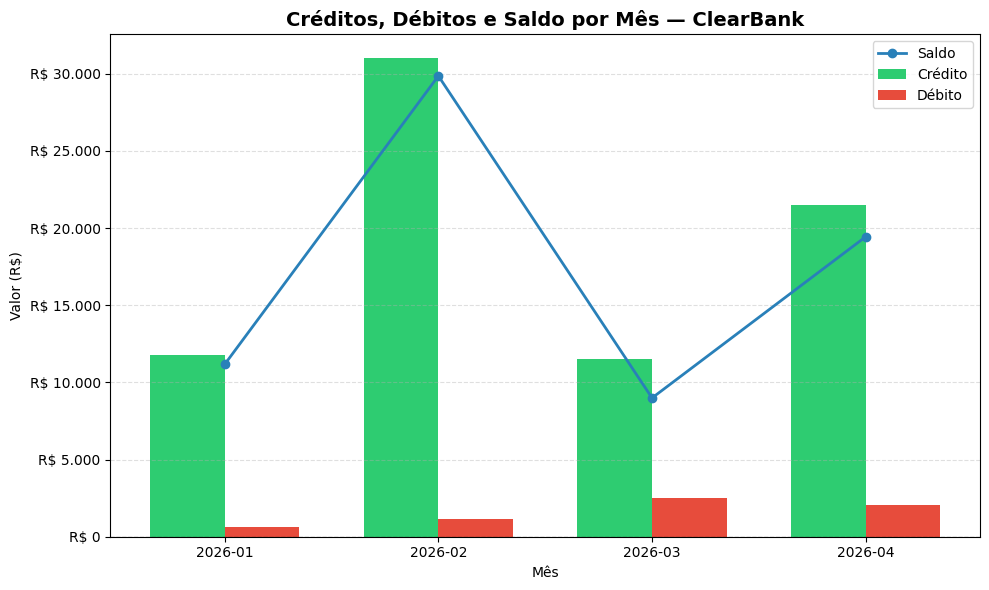

Gráfico salvo em: grafico.png


In [40]:
try:
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker

    # usa relatorio se já foi gerado por main(), senão usa rel_teste (célula 10)
    _rel_grafico = relatorio if 'relatorio' in dir() and relatorio is not None else rel_teste

    meses = list(_rel_grafico['resumo_mensal'].keys())
    creditos = [_rel_grafico['resumo_mensal'][m]['total_credito'] for m in meses]
    debitos  = [_rel_grafico['resumo_mensal'][m]['total_debito']  for m in meses]
    saldos   = [_rel_grafico['resumo_mensal'][m]['saldo']         for m in meses]

    x = range(len(meses))
    largura = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))

    barras_cred = ax.bar([i - largura / 2 for i in x], creditos, largura,
                         label='Crédito', color='#2ecc71')
    barras_deb  = ax.bar([i + largura / 2 for i in x], debitos, largura,
                         label='Débito', color='#e74c3c')

    # linha de saldo
    ax.plot(list(x), saldos, marker='o', color='#2980b9',
            linewidth=2, label='Saldo', zorder=5)

    ax.set_title('Créditos, Débitos e Saldo por Mês — ClearBank', fontsize=14, fontweight='bold')
    ax.set_xlabel('Mês')
    ax.set_ylabel('Valor (R$)')
    ax.set_xticks(list(x))
    ax.set_xticklabels(meses)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f'R$ {v:,.0f}'.replace(',', '.')))
    ax.legend()
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig('grafico.png', dpi=150)
    plt.show()
    print('Gráfico salvo em: grafico.png')

except ImportError:
    print('matplotlib não instalado. Execute: pip install matplotlib')
except Exception as e:
    print(f'[ERRO] ao gerar gráfico: {e}')